## **1. Import Libraries and Dataset**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/monicagayatrik/default-of-credit-card-clients2/default of credit card clients.xls


In [2]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pd.set_option('display.max_columns', None)

In [3]:
df_cc = pd.read_excel('/kaggle/input/datasets/monicagayatrik/default-of-credit-card-clients2/default of credit card clients.xls')

## **2. Data Description**

In [4]:
df_cc.head(6)

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
df_cc.columns = df_cc.iloc[0]
df_cc = df_cc[1:]
df_cc.reset_index(drop=True, inplace=True)
df_cc.head(6)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,0


In [6]:
df_cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          30000 non-null  object
 1   LIMIT_BAL                   30000 non-null  object
 2   SEX                         30000 non-null  object
 3   EDUCATION                   30000 non-null  object
 4   MARRIAGE                    30000 non-null  object
 5   AGE                         30000 non-null  object
 6   PAY_0                       30000 non-null  object
 7   PAY_2                       30000 non-null  object
 8   PAY_3                       30000 non-null  object
 9   PAY_4                       30000 non-null  object
 10  PAY_5                       30000 non-null  object
 11  PAY_6                       30000 non-null  object
 12  BILL_AMT1                   30000 non-null  object
 13  BILL_AMT2                   30000 non-null  ob

In [7]:
df_cc.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object', name=0)

**Detailed column explanation:**

This research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable.

This study reviewed the literature and used the following 23 variables as explanatory variables:

* X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
* X2: Gender (1 = male; 2 = female).
* X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
* X4: Marital status (1 = married; 2 = single; 3 = others).
* X5: Age (year).
* X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
* X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005. 
* X18-X23: Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.

## **3. Data Featuring Engineering**

### **3.1 Missing Data**

In [8]:
len(df_cc.isna())/len(df_cc)

1.0

### **3.2 Duplicate Value**

In [9]:
len(df_cc.duplicated())

30000

### **3.3 Outlier Data**

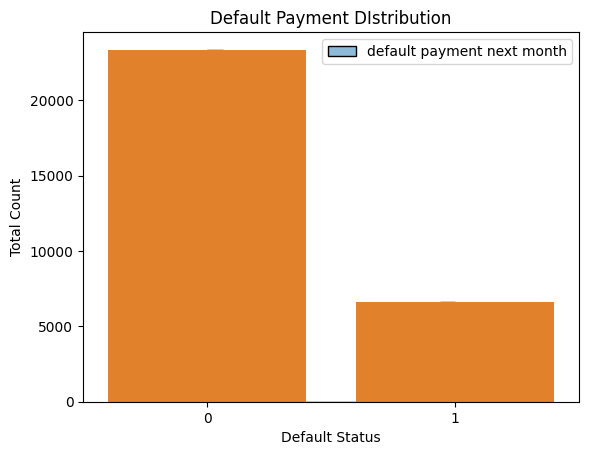

In [10]:
sns.histplot(df_cc[['default payment next month']])

tgt_count = df_cc['default payment next month'].value_counts()
sns.barplot(x=tgt_count.index, y=tgt_count.values)
plt.title('Default Payment DIstribution')
plt.xlabel('Default Status')
plt.ylabel('Total Count')

plt.show()

The appliance showing a huge different total count, between default payment No=0 and Yes=1.

as the dataset don't have any NaN and duplicated values, let's use **StratifiedShuffleSplit** to equally distributed the dataset to training dataset and test dataset.

## **4. Splitting Data Set**

In [11]:
df_cc = df_cc.astype(float)

In [12]:
df_cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  float64
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  float64
 3   EDUCATION                   30000 non-null  float64
 4   MARRIAGE                    30000 non-null  float64
 5   AGE                         30000 non-null  float64
 6   PAY_0                       30000 non-null  float64
 7   PAY_2                       30000 non-null  float64
 8   PAY_3                       30000 non-null  float64
 9   PAY_4                       30000 non-null  float64
 10  PAY_5                       30000 non-null  float64
 11  PAY_6                       30000 non-null  float64
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [13]:
from sklearn.model_selection import StratifiedShuffleSplit

X = df_cc.drop(columns=['default payment next month'])
y = df_cc['default payment next month']
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

In [14]:
for train_index, test_index in sss.split(X, y):
    
    # Extract the training matrices using the generated train_index array
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    
    # Extract the testing matrices using the generated test_index array
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

# Output verification
print(f"Training Matrix Dimensionality: {X_train.shape}")
print(f"Testing Matrix Dimensionality: {X_test.shape}")

Training Matrix Dimensionality: (24000, 24)
Testing Matrix Dimensionality: (6000, 24)


In [15]:
y_train.value_counts(normalize=True)

default payment next month
0.0    0.778792
1.0    0.221208
Name: proportion, dtype: float64

In [16]:
y_test.value_counts(normalize=True)

default payment next month
0.0    0.778833
1.0    0.221167
Name: proportion, dtype: float64

## **5. Apply Feature Scaling**

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **6. Train The Models**

The models that will be trained:
1. Logistic Regression
2. KNN
3. Random Forest
4. Gradient Boosting
5. Stacking Ensemble


Then,we'll compare the score using accuracy, precision, recall, F1-Score, and ROC-AUC

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support as score

### **6.1. Logistic Regression**

In [19]:
print('Logistic Regression Evaluation:')
# create dataframe for metrics
metrics = pd.DataFrame()

# Standard logistic regression
lr_model = LogisticRegression(solver='liblinear').fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

precision_lr, recall_lr = (round(float(x),2) for x in list(score(y_test,
                                                                    y_pred_lr,
                                                                    average='weighted'))[:-2])
# adding lr stats to metrics DataFrame
lr_stats = pd.Series({'Precision':precision_lr,
                      'Recall':recall_lr,
                      'Accuracy':round(accuracy_score(y_test, y_pred_lr), 2),
                      'F1-score':round(f1_score(y_test, y_pred_lr), 2),
                      'AUC': round(roc_auc_score(y_test, y_pred_lr),2)},
                     name='Logistic Regression')
# Report outcomes
print(classification_report(y_test, y_pred_lr))

Logistic Regression Evaluation:
              precision    recall  f1-score   support

         0.0       0.82      0.97      0.89      4673
         1.0       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



### **6.2 K-Nearest Neighbors**

In [20]:
print('KNN Evaluation:')
knn_model = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn = knn_model.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

precision_knn, recall_knn = (round(float(x),2) for x in list(score(y_test,
                                                                      y_pred_knn,
                                                                      average='weighted'))[:-2])
# adding KNN stats to metrics DataFrame
knn_stats = pd.Series({'Precision':precision_knn,
                      'Recall':recall_knn,
                      'Accuracy':round(accuracy_score(y_test, y_pred_knn), 2),
                      'F1-score':round(f1_score(y_test, y_pred_knn), 2),
                      'AUC': round(roc_auc_score(y_test, y_pred_knn),2)}, name='KNN')
# Report outcomes
print(classification_report(y_test, y_pred_knn))

KNN Evaluation:
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      4673
         1.0       0.48      0.36      0.41      1327

    accuracy                           0.77      6000
   macro avg       0.66      0.62      0.63      6000
weighted avg       0.75      0.77      0.76      6000



### **6.3 Random Forest**

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

print('Random Forest Evaluation:')
rfc_model = RandomForestClassifier(n_estimators=100, min_samples_split=2, max_features=1.0, max_depth=15, random_state=42)
rfc = rfc_model.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)

precision_rfc, recall_rfc = (round(float(x),2) for x in list(score(y_test,
                                                                      y_pred_rfc,
                                                                      average='weighted'))[:-2])
# adding gradient boosting stats to metrics DataFrame
rfc_stats = pd.Series({'Precision':precision_rfc,
                      'Recall':recall_rfc,
                      'Accuracy':round(accuracy_score(y_test, y_pred_rfc), 2),
                      'F1-score':round(f1_score(y_test, y_pred_rfc), 2),
                      'AUC': round(roc_auc_score(y_test, y_pred_rfc),2)}, name='Random Forest')
# Report outcomes
print(classification_report(y_test, y_pred_rfc))

Random Forest Evaluation:
              precision    recall  f1-score   support

         0.0       0.84      0.95      0.89      4673
         1.0       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



### **6.4 Gradient Boosting**

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

print('Gradient Boosting Evaluation:')
gbclass_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc = gbclass_model.fit(X_train, y_train)
y_pred_gbc = gbc.predict(X_test)

precision_gbc, recall_gbc = (round(float(x),2) for x in list(score(y_test,
                                                                      y_pred_gbc,
                                                                      average='weighted'))[:-2])
# adding gradient boosting stats to metrics DataFrame
gbc_stats = pd.Series({'Precision':precision_gbc,
                      'Recall':recall_gbc,
                      'Accuracy':round(accuracy_score(y_test, y_pred_gbc), 2),
                      'F1-score':round(f1_score(y_test, y_pred_gbc), 2),
                      'AUC': round(roc_auc_score(y_test, y_pred_gbc),2)}, name='Gradient Boosting')
# Report outcomes
print(classification_report(y_test, y_pred_gbc))

Gradient Boosting Evaluation:
              precision    recall  f1-score   support

         0.0       0.84      0.95      0.89      4673
         1.0       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



### **6.5 Stacking Ensamble**

In [23]:
from sklearn.ensemble import StackingClassifier

print('Stacking Ensemble Evaluation:')


estimators_list = [
    ('lr', lr_model),
    ('knn', knn_model),
    ('rfc', rfc_model),
    ('gbc', gbclass_model)
]


stacking_model = StackingClassifier(
    estimators=estimators_list,
    final_estimator=LogisticRegression(solver='liblinear'),
    cv=5,
    n_jobs=-1 
)

stack_clf = stacking_model.fit(X_train, y_train)
y_pred_stack = stack_clf.predict(X_test)


precision_stack, recall_stack = (round(float(x),2) for x in list(score(y_test, 
                                                                      y_pred_stack, 
                                                                      average='weighted'))[:-2])


stack_stats = pd.Series({'Precision': precision_stack,
                         'Recall': recall_stack,
                         'Accuracy': round(accuracy_score(y_test, y_pred_stack), 2),
                         'F1-score': round(f1_score(y_test, y_pred_stack), 2),
                         'AUC': round(roc_auc_score(y_test, y_pred_stack), 2)}, # Catatan: Secara matematis suboptimal tanpa predict_proba
                        name='Stacking Ensemble')


print(classification_report(y_test, y_pred_stack))

Stacking Ensemble Evaluation:
              precision    recall  f1-score   support

         0.0       0.84      0.95      0.89      4673
         1.0       0.68      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



## **7. Model Evaluation Comparison**

In [24]:
metrics_df = pd.concat([lr_stats, knn_stats, rfc_stats, gbc_stats, stack_stats], axis=1).T
metrics_df = metrics_df.sort_values(by='Recall', ascending=False)

print("\n---------------- Final Metrics Comparison Matrix -----------------\n")
print(metrics_df)


---------------- Final Metrics Comparison Matrix -----------------

                     Precision  Recall  Accuracy  F1-score   AUC
Random Forest             0.80    0.82      0.82      0.47  0.66
Stacking Ensemble         0.80    0.82      0.82      0.47  0.66
Gradient Boosting         0.80    0.82      0.82      0.47  0.66
Logistic Regression       0.79    0.81      0.81      0.36  0.61
KNN                       0.75    0.77      0.77      0.41  0.62


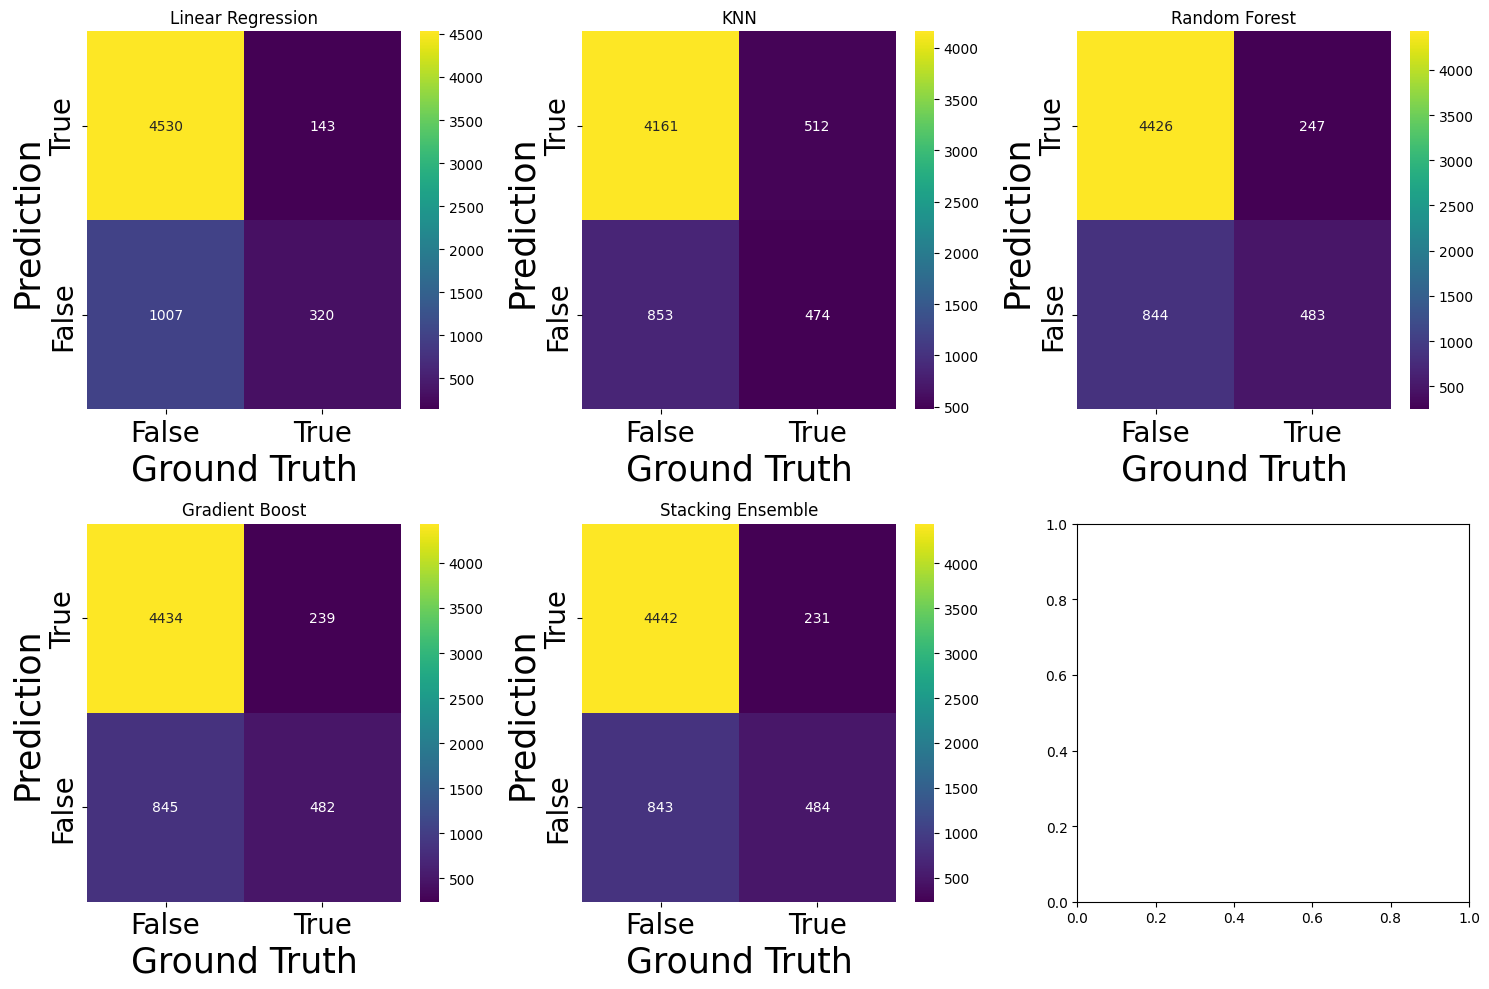

In [25]:
fig, axList = plt.subplots(nrows=2, ncols=3)
axList = axList.flatten()
fig.set_size_inches(15, 10)


models = coeff_labels = ['Linear Regression', 'KNN', 'Random Forest', 'Gradient Boost', 'Stacking Ensemble']
cm = [confusion_matrix(y_test, y_pred_lr),
      confusion_matrix(y_test, y_pred_knn),
      confusion_matrix(y_test, y_pred_rfc),
      confusion_matrix(y_test, y_pred_gbc),
      confusion_matrix(y_test, y_pred_stack)]
labels = ['False', 'True']

for ax,model, idx in zip(axList, models, range(0,5)):
    sns.heatmap(cm[idx], ax=ax, annot=True, fmt='d', cmap='viridis');
    ax.set(title=model);
    ax.set_xticklabels(labels, fontsize=20);
    ax.set_yticklabels(labels[::-1], fontsize=20);
    ax.set_ylabel('Prediction', fontsize=25);
    ax.set_xlabel('Ground Truth', fontsize=25)
    
plt.tight_layout()